# Data Import

In [74]:
#install.packages('caret')
#install.packages('ordinalNet')
#install.packages('fastDummies')
#install.packages('janitor')
#install.packages('pROC')

In [1]:
library(caret)
library(glmnet)
library(fastDummies)
library(ordinalNet)
library(janitor)
library(plyr)
library(pROC)
library(tidyverse)  # Data wrangling packages.
library(dplyr)

# This snippet assumes that you run setup first

# This code copies a file from your Google Bucket into a dataframe

# replace 'test.csv' with the name of the file in your google bucket (don't delete the quotation marks)
name_of_file_in_bucket <- 'cleaned_data.csv'

########################################################################
##
################# DON'T CHANGE FROM HERE ###############################
##
########################################################################

# Get the bucket name
my_bucket <- Sys.getenv('WORKSPACE_BUCKET')

# Copy the file from current workspace to the bucket
system(paste0("gsutil cp ", my_bucket, "/data/", name_of_file_in_bucket, " ."), intern=T)

# Load the file into a dataframe
my_dataframe  <- read_csv(name_of_file_in_bucket)
df <- my_dataframe
print(dim(df))
head(df)

Loading required package: ggplot2

Loading required package: lattice

Loading required package: Matrix

Loaded glmnet 4.1-8

Thank you for using fastDummies!

To acknowledge our work, please cite the package:

Kaplan, J. & Schlegel, B. (2023). fastDummies: Fast Creation of Dummy (Binary) Columns and Rows from Categorical Variables. Version 1.7.1. URL: https://github.com/jacobkap/fastDummies, https://jacobkap.github.io/fastDummies/.


Attaching package: ‘janitor’


The following objects are masked from ‘package:stats’:

    chisq.test, fisher.test


Type 'citation("pROC")' for a citation.


Attaching package: ‘pROC’


The following objects are masked from ‘package:stats’:

    cov, smooth, var


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ lubridate 1.9.3     ✔ tibble    3.2.1
✔ purrr     1.0.2     ✔ tidyr     1.3.1
── Conflicts ──────────────────────────────────────────

character(0)

Rows: 35923 Columns: 90
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (88): gender, race, ethnicity, ADHD, Acid Reflux, Acne, Alcohol Or Drug,...
dbl  (2): person_id, age_years

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] 35923    90


person_id,gender,race,ethnicity,age_years,ADHD,Acid Reflux,Acne,Alcohol Or Drug,Allergies,⋯,Type 2 Diabetes,Urinary Tract,Vitamin B Deficiency,Vitamin D Deficiency,Yeast Infection,General Health,General Mental Health,General Physical Health,General Quality,General Social
<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
2272845,Unknown/Missing,Unknown/Missing,Unknown/Missing,19,No,No,No,No,No,⋯,No,No,No,No,No,Very Good,Good,Very Good,Good,Very Good
2061175,Unknown/Missing,Unknown/Missing,Unknown/Missing,23,Yes,No,No,Yes,No,⋯,No,No,No,No,No,Fair,Good,Good,Fair,Good
2987154,Unknown/Missing,Unknown/Missing,Unknown/Missing,35,No,No,No,No,Yes,⋯,No,No,No,No,No,Poor,Good,Poor,Fair,Fair
1877627,Unknown/Missing,Unknown/Missing,Unknown/Missing,29,No,No,No,No,Yes,⋯,No,No,No,No,No,Excellent,Good,Very Good,Very Good,Fair
1272732,Other,Unknown/Missing,Unknown/Missing,25,No,No,No,No,No,⋯,No,No,No,No,No,Fair,Poor,Fair,Fair,Fair
1750918,Male,Unknown/Missing,Unknown/Missing,30,No,No,No,No,No,⋯,No,No,No,No,No,Very Good,Fair,Good,Poor,Fair


# Clean Data

In [2]:
# make predictor variable values numeric
num_preds <- df

num_preds[num_preds == 'Yes'] <- '1'
num_preds[num_preds == 'No'] <- '0'
head(num_preds)

person_id,gender,race,ethnicity,age_years,ADHD,Acid Reflux,Acne,Alcohol Or Drug,Allergies,⋯,Type 2 Diabetes,Urinary Tract,Vitamin B Deficiency,Vitamin D Deficiency,Yeast Infection,General Health,General Mental Health,General Physical Health,General Quality,General Social
<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
2272845,Unknown/Missing,Unknown/Missing,Unknown/Missing,19,0,0,0,0,0,⋯,0,0,0,0,0,Very Good,Good,Very Good,Good,Very Good
2061175,Unknown/Missing,Unknown/Missing,Unknown/Missing,23,1,0,0,1,0,⋯,0,0,0,0,0,Fair,Good,Good,Fair,Good
2987154,Unknown/Missing,Unknown/Missing,Unknown/Missing,35,0,0,0,0,1,⋯,0,0,0,0,0,Poor,Good,Poor,Fair,Fair
1877627,Unknown/Missing,Unknown/Missing,Unknown/Missing,29,0,0,0,0,1,⋯,0,0,0,0,0,Excellent,Good,Very Good,Very Good,Fair
1272732,Other,Unknown/Missing,Unknown/Missing,25,0,0,0,0,0,⋯,0,0,0,0,0,Fair,Poor,Fair,Fair,Fair
1750918,Male,Unknown/Missing,Unknown/Missing,30,0,0,0,0,0,⋯,0,0,0,0,0,Very Good,Fair,Good,Poor,Fair


In [3]:
# create dummy variables
dummy_df <- dummy_cols(num_preds, select_columns = c('gender', 'race', 'ethnicity'))
dummy_df <- dummy_df |> select(-c(gender, race, ethnicity, person_id))
head(dummy_df)

age_years,ADHD,Acid Reflux,Acne,Alcohol Or Drug,Allergies,Anemia,Anxiety,Asthma,Astigmatism,⋯,gender_Unknown/Missing,race_Asian,race_Black,race_Middle Eastern,race_More than one,race_Unknown/Missing,race_White,ethnicity_Hispanic/Latino,ethnicity_Not Hispanic/Latino,ethnicity_Unknown/Missing
<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
19,0,0,0,0,0,0,1,0,1,⋯,1,0,0,0,0,1,0,0,0,1
23,1,0,0,1,0,0,1,0,0,⋯,1,0,0,0,0,1,0,0,0,1
35,0,0,0,0,1,0,0,0,0,⋯,1,0,0,0,0,1,0,0,0,1
29,0,0,0,0,1,0,0,0,0,⋯,1,0,0,0,0,1,0,0,0,1
25,0,0,0,0,0,0,0,0,1,⋯,0,0,0,0,0,1,0,0,0,1
30,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,1,0,0,0,1


In [4]:
# move quality variables to end of dataframe
moved_df <- dummy_df |> 
    relocate(c(`General Mental Health`, `General Physical Health`,
               `General Quality`, `General Social`, `General Health`), 
             .after = last_col())

head(moved_df)

age_years,ADHD,Acid Reflux,Acne,Alcohol Or Drug,Allergies,Anemia,Anxiety,Asthma,Astigmatism,⋯,race_Unknown/Missing,race_White,ethnicity_Hispanic/Latino,ethnicity_Not Hispanic/Latino,ethnicity_Unknown/Missing,General Mental Health,General Physical Health,General Quality,General Social,General Health
<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<int>,<int>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>
19,0,0,0,0,0,0,1,0,1,⋯,1,0,0,0,1,Good,Very Good,Good,Very Good,Very Good
23,1,0,0,1,0,0,1,0,0,⋯,1,0,0,0,1,Good,Good,Fair,Good,Fair
35,0,0,0,0,1,0,0,0,0,⋯,1,0,0,0,1,Good,Poor,Fair,Fair,Poor
29,0,0,0,0,1,0,0,0,0,⋯,1,0,0,0,1,Good,Very Good,Very Good,Fair,Excellent
25,0,0,0,0,0,0,0,0,1,⋯,1,0,0,0,1,Poor,Fair,Fair,Fair,Fair
30,0,0,0,0,0,0,0,0,0,⋯,1,0,0,0,1,Fair,Good,Poor,Fair,Very Good


In [5]:
# make quality values continuous
num_out <- moved_df

num_out[num_out == 'Poor'] <- '1'
num_out[num_out == 'Fair'] <- '2.05'
num_out[num_out == 'Good'] <- '3.58'
num_out[num_out == 'Very Good'] <- '4.7'
num_out[num_out == 'Excellent'] <- '5'
num_out[num_out == 'Unknown'] <- '0'

num_out <- mutate_all(num_out, function(x) as.numeric(as.character(x))) 
                      
num_out <- num_out |> clean_names()

head(num_out)

age_years,adhd,acid_reflux,acne,alcohol_or_drug,allergies,anemia,anxiety,asthma,astigmatism,⋯,race_unknown_missing,race_white,ethnicity_hispanic_latino,ethnicity_not_hispanic_latino,ethnicity_unknown_missing,general_mental_health,general_physical_health,general_quality,general_social,general_health
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
19,0,0,0,0,0,0,1,0,1,⋯,1,0,0,0,1,3.58,4.70,3.58,4.70,4.70
23,1,0,0,1,0,0,1,0,0,⋯,1,0,0,0,1,3.58,3.58,2.05,3.58,2.05
35,0,0,0,0,1,0,0,0,0,⋯,1,0,0,0,1,3.58,1.00,2.05,2.05,1.00
29,0,0,0,0,1,0,0,0,0,⋯,1,0,0,0,1,3.58,4.70,4.70,2.05,5.00
25,0,0,0,0,0,0,0,0,1,⋯,1,0,0,0,1,1.00,2.05,2.05,2.05,2.05
30,0,0,0,0,0,0,0,0,0,⋯,1,0,0,0,1,2.05,3.58,1.00,2.05,4.70


In [6]:
# take out age since it is continuous
num_out <- num_out |> select(-age_years)
head(num_out)

adhd,acid_reflux,acne,alcohol_or_drug,allergies,anemia,anxiety,asthma,astigmatism,atrial_fibrillation,⋯,race_unknown_missing,race_white,ethnicity_hispanic_latino,ethnicity_not_hispanic_latino,ethnicity_unknown_missing,general_mental_health,general_physical_health,general_quality,general_social,general_health
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0,0,0,0,0,0,1,0,1,0,⋯,1,0,0,0,1,3.58,4.70,3.58,4.70,4.70
1,0,0,1,0,0,1,0,0,0,⋯,1,0,0,0,1,3.58,3.58,2.05,3.58,2.05
0,0,0,0,1,0,0,0,0,0,⋯,1,0,0,0,1,3.58,1.00,2.05,2.05,1.00
0,0,0,0,1,0,0,0,0,0,⋯,1,0,0,0,1,3.58,4.70,4.70,2.05,5.00
0,0,0,0,0,0,0,0,1,0,⋯,1,0,0,0,1,1.00,2.05,2.05,2.05,2.05
0,0,0,0,0,0,0,0,0,0,⋯,1,0,0,0,1,2.05,3.58,1.00,2.05,4.70


# Ordinal 

In [5]:
ord <- moved_df |> select(-c(`General Mental Health`, `General Physical Health`,
                             `General Quality`, `General Social`))

# drop values with unknown outcome
ord <- ord[ord$`General Health` != 'Unknown', ]

print(dim(ord))
head(ord)

[1] 35814    96


age_years,ADHD,Acid Reflux,Acne,Alcohol Or Drug,Allergies,Anemia,Anxiety,Asthma,Astigmatism,⋯,race_Black,race_Middle Eastern,race_More than one,race_Pacific Islander,race_Unknown/Missing,race_White,ethnicity_Hispanic/Latino,ethnicity_Not Hispanic/Latino,ethnicity_Unknown/Missing,General Health
<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<chr>
27,0,0,0,0,0,0,1,0,0,⋯,0,0,0,0,1,0,0,0,1,Poor
39,0,1,0,0,1,0,0,1,0,⋯,0,0,0,0,1,0,0,0,1,Good
39,0,1,0,0,1,0,0,0,0,⋯,0,0,0,0,1,0,0,0,1,Fair
38,0,0,0,0,1,0,0,0,0,⋯,0,0,0,0,1,0,0,0,1,Good
37,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,1,0,0,0,1,Very Good
37,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,1,0,0,0,1,Fair


In [6]:
# create x dataset
x_data <- ord |> select(-`General Health`)

# make values numeric
x_data <- mutate_all(x_data, function(x) as.numeric(as.character(x)))     
x_data <- data.matrix(x_data)

head(x_data)

age_years,ADHD,Acid Reflux,Acne,Alcohol Or Drug,Allergies,Anemia,Anxiety,Asthma,Astigmatism,⋯,race_Asian,race_Black,race_Middle Eastern,race_More than one,race_Pacific Islander,race_Unknown/Missing,race_White,ethnicity_Hispanic/Latino,ethnicity_Not Hispanic/Latino,ethnicity_Unknown/Missing
27,0,0,0,0,0,0,1,0,0,⋯,0,0,0,0,0,1,0,0,0,1
39,0,1,0,0,1,0,0,1,0,⋯,0,0,0,0,0,1,0,0,0,1
39,0,1,0,0,1,0,0,0,0,⋯,0,0,0,0,0,1,0,0,0,1
38,0,0,0,0,1,0,0,0,0,⋯,0,0,0,0,0,1,0,0,0,1
37,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,1,0,0,0,1
37,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,1,0,0,0,1


In [7]:
# create y dataset
y_data <- ord$`General Health`
y_data <- ordered(y_data, levels = c('Poor', 'Fair', 'Good', 'Very Good', 'Excellent'))
is.ordered(y_data)

[1] TRUE

In [8]:
# ordinalNet package - https://cran.r-project.org/web/packages/ordinalNet/ordinalNet.pdf
# takes about an hour
ord_test <- ordinalNet(x_data, y_data, family = "cumulative", link = "logit",
                       parallelTerms = FALSE, nonparallelTerms = TRUE)

coef(ord_test, matrix = TRUE)

Warning message in ordinalNet(x_data, y_data, family = "cumulative", link = "logit", :
“For out-of-sample data, the cumulative probability model with nonparallelTerms=TRUE may predict cumulative probabilities that are not monotone increasing.”


,logit(P[Y<=1]),logit(P[Y<=2]),logit(P[Y<=3]),logit(P[Y<=4])
(Intercept),-3.538324,-1.88980834,-2.557184e-01,1.79392816
age_years,0.000000,0.00000000,1.269153e-03,0.00000000
ADHD,0.000000,0.00000000,1.660153e-02,0.00000000
Acid Reflux,0.000000,0.28711232,3.365097e-01,0.15640401
Acne,0.000000,0.00000000,-1.150856e-04,0.00000000
Alcohol Or Drug,0.000000,0.00000000,0.000000e+00,0.00000000
Allergies,0.000000,0.00000000,0.000000e+00,0.00000000
Anemia,0.000000,0.12585534,1.355560e-01,0.00000000
Anxiety,0.000000,0.00000000,9.764195e-02,0.17059940
Asthma,0.000000,0.11403119,9.342296e-02,0.00000000


In [10]:
ord_coef <- coef(ord_test, matrix = TRUE)
ord_coef

,logit(P[Y<=1]),logit(P[Y<=2]),logit(P[Y<=3]),logit(P[Y<=4])
(Intercept),-3.538324,-1.88980834,-2.557184e-01,1.79392816
age_years,0.000000,0.00000000,1.269153e-03,0.00000000
ADHD,0.000000,0.00000000,1.660153e-02,0.00000000
Acid Reflux,0.000000,0.28711232,3.365097e-01,0.15640401
Acne,0.000000,0.00000000,-1.150856e-04,0.00000000
Alcohol Or Drug,0.000000,0.00000000,0.000000e+00,0.00000000
Allergies,0.000000,0.00000000,0.000000e+00,0.00000000
Anemia,0.000000,0.12585534,1.355560e-01,0.00000000
Anxiety,0.000000,0.00000000,9.764195e-02,0.17059940
Asthma,0.000000,0.11403119,9.342296e-02,0.00000000


In [18]:
# save coefficients so don't have to run again
ord_df <- as.data.frame(ord_coef)

# make index/predictors own variaable
ord_final <- cbind(comorbidity = rownames(ord_df), ord_df)
rownames(ord_final) <- 1:nrow(ord_final)
head(ord_final)

,comorbidity,logit(P[Y<=1]),logit(P[Y<=2]),logit(P[Y<=3]),logit(P[Y<=4])
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,(Intercept),-3.538324,-1.8898083,-0.2557184473,1.793928
2,age_years,0.000000,0.0000000,0.0012691528,0.000000
3,ADHD,0.000000,0.0000000,0.0166015295,0.000000
4,Acid Reflux,0.000000,0.2871123,0.3365096882,0.156404
5,Acne,0.000000,0.0000000,-0.0001150856,0.000000
6,Alcohol Or Drug,0.000000,0.0000000,0.0000000000,0.000000


In [21]:
# This snippet assumes that you run setup first

# This code saves your dataframe into a csv file in a "data" folder in Google Bucket

# Replace df with THE NAME OF YOUR DATAFRAME
my_dataframe <- ord_final

# Replace 'test.csv' with THE NAME of the file you're going to store in the bucket (don't delete the quotation marks)
destination_filename <- 'ordinal_coef.csv'

########################################################################
##
################# DON'T CHANGE FROM HERE ###############################
##
########################################################################

# store the dataframe in current workspace
write_excel_csv(my_dataframe, destination_filename)

# Get the bucket name
my_bucket <- Sys.getenv('WORKSPACE_BUCKET')

# Copy the file from current workspace to the bucket
system(paste0("gsutil cp ./", destination_filename, " ", my_bucket, "/data/"), intern=T)

# Check if file is in the bucket
system(paste0("gsutil ls ", my_bucket, "/data/*.csv"), intern=T)


character(0)

[1] "gs://fc-secure-094fc0a0-519f-48e9-9547-6ae9fa803d5c/data/basic_overall.csv"       
[2] "gs://fc-secure-094fc0a0-519f-48e9-9547-6ae9fa803d5c/data/combined3.csv"           
[3] "gs://fc-secure-094fc0a0-519f-48e9-9547-6ae9fa803d5c/data/mm_subset1.csv"          
[4] "gs://fc-secure-094fc0a0-519f-48e9-9547-6ae9fa803d5c/data/ordinal_coef.csv"        
[5] "gs://fc-secure-094fc0a0-519f-48e9-9547-6ae9fa803d5c/data/overall_basic1.csv"      
[6] "gs://fc-secure-094fc0a0-519f-48e9-9547-6ae9fa803d5c/data/overall_basic_clean1.csv"
[7] "gs://fc-secure-094fc0a0-519f-48e9-9547-6ae9fa803d5c/data/test.csv"                
[8] "gs://fc-secure-094fc0a0-519f-48e9-9547-6ae9fa803d5c/data/test_dataset1.csv"

In [22]:
# This snippet assumes that you run setup first

# This code copies a file from your Google Bucket into a dataframe

# replace 'test.csv' with the name of the file in your google bucket (don't delete the quotation marks)
name_of_file_in_bucket <- 'ordinal_coef.csv'

########################################################################
##
################# DON'T CHANGE FROM HERE ###############################
##
########################################################################

# Get the bucket name
my_bucket <- Sys.getenv('WORKSPACE_BUCKET')

# Copy the file from current workspace to the bucket
system(paste0("gsutil cp ", my_bucket, "/data/", name_of_file_in_bucket, " ."), intern=T)

# Load the file into a dataframe
my_dataframe  <- read_csv(name_of_file_in_bucket)
head(my_dataframe)


character(0)

Rows: 96 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): comorbidity
dbl (4): logit(P[Y<=1]), logit(P[Y<=2]), logit(P[Y<=3]), logit(P[Y<=4])

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


comorbidity,logit(P[Y<=1]),logit(P[Y<=2]),logit(P[Y<=3]),logit(P[Y<=4])
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),-3.538324,-1.8898083,-0.2557184473,1.793928
age_years,0.000000,0.0000000,0.0012691528,0.000000
ADHD,0.000000,0.0000000,0.0166015295,0.000000
Acid Reflux,0.000000,0.2871123,0.3365096882,0.156404
Acne,0.000000,0.0000000,-0.0001150856,0.000000
Alcohol Or Drug,0.000000,0.0000000,0.0000000000,0.000000


# Continuous

In [6]:
# function to create lasso model based on desired outcome variable
get_lasso_coef_continuous <- function(numeric_dataframe, outcome_variable) {
    # create array of variables to remove    
    outcome_var_list <- c('general_mental_health', 'general_physical_health',
                          'general_quality', 'general_social', 'general_health')
    remove_other_outcomes <- outcome_var_list[outcome_var_list != outcome_variable]
        
    # remove unwanted outcome variables
    cont_data <- numeric_dataframe |> select(-remove_other_outcomes)

    # drop values with unknown outcome
    cont_data <- cont_data[cont_data[outcome_variable] != 0,]

    # make x and y datasets
    x_data <- cont_data |> select(-outcome_variable)
    x_data <- data.matrix(x_data)
    y_data_df <- cont_data[outcome_variable]
    y_data <- unlist(y_data_df, use.names = FALSE)
    print(table(y_data))

    # lasso with cross validation - calculate minimum lambda
    set.seed(123)
    model <- cv.glmnet(x_data, y_data, alpha = 1, nfolds = 10)
    lambda_val <- model$lambda.min
    print(lambda_val)
    plot(model)
    
    # get coefficients - model with minimum lambda
    model_small_lambda <- glmnet(x_data, y_data, lambda = lambda_val, alpha = 1)
    res <- coef(model_small_lambda)
    return(res)
}

y_data
    1  2.05  3.58   4.7     5 
 1072  4821 11952 13433  4536 
[1] 0.002354532


96 x 1 sparse Matrix of class "dgCMatrix"
                                             s0
(Intercept)                         4.159657865
age_years                           0.000712587
ADHD                               -0.050411596
Acid Reflux                        -0.181781707
Acne                                0.174844146
Alcohol Or Drug                    -0.033040550
Allergies                           0.046427322
Anemia                             -0.160257594
Anxiety                            -0.054620774
Asthma                             -0.122336849
Astigmatism                         0.016085551
Atrial Fibrillation                -0.199129864
Bipolar                            -0.189761373
Breast Cancer                      -0.343805865
Carpal Tunnel                       .          
Cataracts                          -0.152287237
Chickenpox                         -0.105568896
Chronic Fatigue                    -0.388013447
Chronic Sinus                       .         

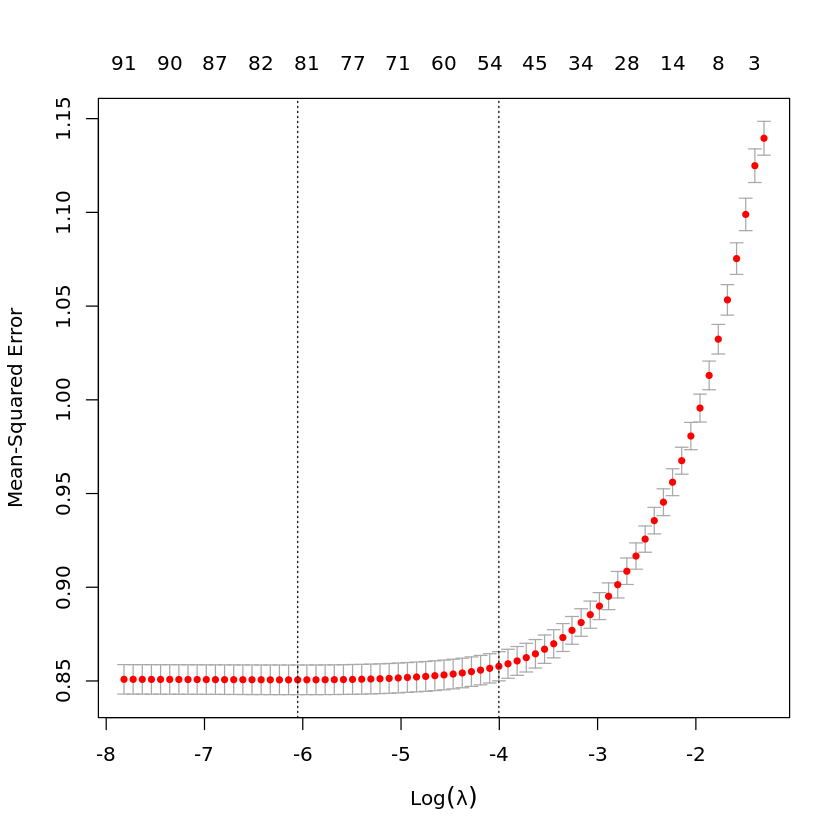

In [75]:
get_lasso_coef_continuous(num_out, 'general_health')

# Binary

In [7]:
# function to create lasso model based on desired outcome variable
get_lasso_coef_binary <- function(numeric_dataframe, outcome_variable) {
    # create array of variables to remove    
    outcome_var_list <- c('general_mental_health', 'general_physical_health',
                          'general_quality', 'general_social', 'general_health')
    remove_other_outcomes <- outcome_var_list[outcome_var_list != outcome_variable]
        
    # remove unwanted outcome variables
    cont_data <- numeric_dataframe |> select(-remove_other_outcomes)

    # drop values with unknown outcome
    cont_data <- cont_data[cont_data[outcome_variable] != 0,]

    # make x and y datasets
    x_data <- cont_data |> select(-outcome_variable)
    x_data <- data.matrix(x_data)
    y_data_df <- cont_data[outcome_variable]
    y_data <- unlist(y_data_df, use.names = FALSE)
    print(table(y_data))
    
    # make outcome variable binary
    y_data <- replace(y_data, y_data == 1, 0)
    y_data <- replace(y_data, y_data == 2.05, 0)
    y_data <- replace(y_data, y_data == 3.58, 1)
    y_data <- replace(y_data, y_data == 4.7, 1)
    y_data <- replace(y_data, y_data == 5, 1)
    print(table(y_data))

    # lasso with cross validation - calculate minimum lambda
    set.seed(123)
    model <- cv.glmnet(x_data, as.factor(y_data), alpha = 1, nfolds = 10, family = 'binomial')
    lambda_val <- model$lambda.min
    print(lambda_val)
    plot(model)
    
    # get coefficients - model with minimum lambda
    model_small_lambda <- glmnet(x_data, as.factor(y_data), lambda = lambda_val, alpha = 1, family = 'binomial')
    res <- coef(model_small_lambda)
    return(res)
}

y_data
    1  2.05  3.58   4.7     5 
 1072  4821 11952 13433  4536 
y_data
    0     1 
 5893 29921 
[1] 0.0006426364


96 x 1 sparse Matrix of class "dgCMatrix"
                                             s0
(Intercept)                         2.102456113
age_years                           0.008123429
ADHD                               -0.041721800
Acid Reflux                        -0.318684183
Acne                                0.372646943
Alcohol Or Drug                    -0.078537061
Allergies                           0.122960048
Anemia                             -0.298251646
Anxiety                            -0.071902887
Asthma                             -0.285179518
Astigmatism                         0.138827806
Atrial Fibrillation                -0.612821818
Bipolar                            -0.377869436
Breast Cancer                      -0.862355457
Carpal Tunnel                       .          
Cataracts                          -0.317320815
Chickenpox                         -0.266009281
Chronic Fatigue                    -0.735192650
Chronic Sinus                      -0.00794907

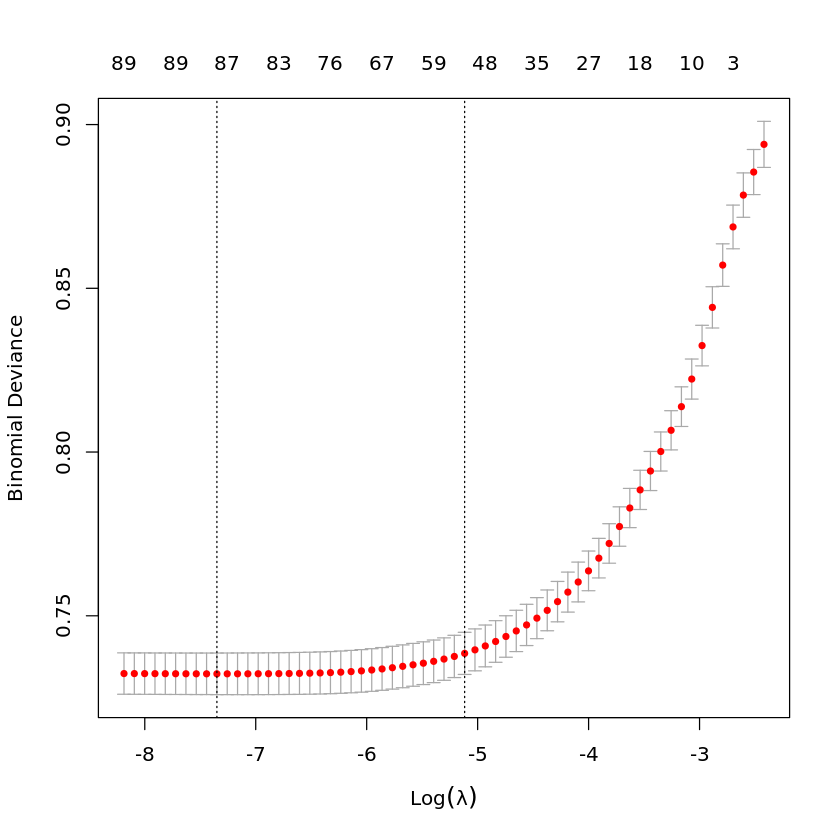

In [87]:
get_lasso_coef_binary(num_out, 'general_health')

# Combined continuous, binary lasso model

In [7]:
# function to create lasso model based on desired outcome variable type
get_lasso_coef <- function(numeric_dataframe, outcome_variable, is_binary, max_df = dim(numeric_dataframe)[2]) {
    # create array of variables to remove    
    outcome_var_list <- c('general_mental_health', 'general_physical_health',
                          'general_quality', 'general_social', 'general_health')
    remove_other_outcomes <- outcome_var_list[outcome_var_list != outcome_variable]
        
    # remove unwanted outcome variables
    cont_data <- numeric_dataframe |> select(-remove_other_outcomes)

    # drop values with unknown outcome
    cont_data <- cont_data[cont_data[outcome_variable] != 0,]

    # make x and y datasets
    x_data <- cont_data |> select(-outcome_variable)
    x_data <- data.matrix(x_data)
    y_data_df <- cont_data[outcome_variable]
    y_data <- unlist(y_data_df, use.names = FALSE)
    print(table(y_data))
    
    if (is_binary == 1) {
        # make outcome variable binary
        y_data <- replace(y_data, y_data == 1, 0)
        y_data <- replace(y_data, y_data == 2.05, 0)
        y_data <- replace(y_data, y_data == 3.58, 1)
        y_data <- replace(y_data, y_data == 4.7, 1)
        y_data <- replace(y_data, y_data == 5, 1)
        print(table(y_data))

        # lasso with cross validation - calculate minimum lambda
        set.seed(123)
        model <- cv.glmnet(x_data, as.factor(y_data), alpha = 1, nfolds = 10, family = 'binomial',
                           dfmax = max_df)
        lambda_val <- model$lambda.min
        print(lambda_val)
        plot(model)

        # get coefficients - model with minimum lambda
        model_small_lambda <- glmnet(x_data, as.factor(y_data), lambda = lambda_val, alpha = 1, family = 'binomial',
                                     dfmax = max_df)
        coef_result <- coef(model_small_lambda)
    }
    else {
        # lasso with cross validation - calculate minimum lambda
        set.seed(123)
        model <- cv.glmnet(x_data, y_data, alpha = 1, nfolds = 10, 
                           dfmax = max_df)
        lambda_val <- model$lambda.min
        print(lambda_val)
        plot(model)

        # get coefficients - model with minimum lambda
        model_small_lambda <- glmnet(x_data, y_data, lambda = lambda_val, alpha = 1, 
                                     dfmax = max_df)
        coef_result <- coef(model_small_lambda)
    }
    # return coefficients as dataframe
    coef_matrix <- as.matrix(coef_result)
    coef_matrix_df <- as.data.frame(coef_matrix)
    coef_matrix_df <- cbind(comorbidity = rownames(coef_matrix_df), coef_matrix_df)
    rownames(coef_matrix_df) <- 1:nrow(coef_matrix_df)
    colnames(coef_matrix_df) <- c('comorbidity', 'value')
    return(coef_matrix_df)
}

Warning message:
“Using an external vector in selections was deprecated in tidyselect 1.1.0.
ℹ Please use `all_of()` or `any_of()` instead.
  # Was:
  data %>% select(remove_other_outcomes)

  # Now:
  data %>% select(all_of(remove_other_outcomes))

See <https://tidyselect.r-lib.org/reference/faq-external-vector.html>.”
Warning message:
“Using an external vector in selections was deprecated in tidyselect 1.1.0.
ℹ Please use `all_of()` or `any_of()` instead.
  # Was:
  data %>% select(outcome_variable)

  # Now:
  data %>% select(all_of(outcome_variable))

See <https://tidyselect.r-lib.org/reference/faq-external-vector.html>.”


y_data
    1  2.05  3.58   4.7     5 
 1072  4821 11952 13433  4536 
[1] 0.002145362


,comorbidity,value
,<chr>,<dbl>
1,(Intercept),4.17535042
2,adhd,-0.05147430
3,acid_reflux,-0.18216417
4,acne,0.17431798
5,alcohol_or_drug,-0.03571798
6,allergies,0.04773915
7,anemia,-0.16238119
8,anxiety,-0.05550264
9,asthma,-0.12373585


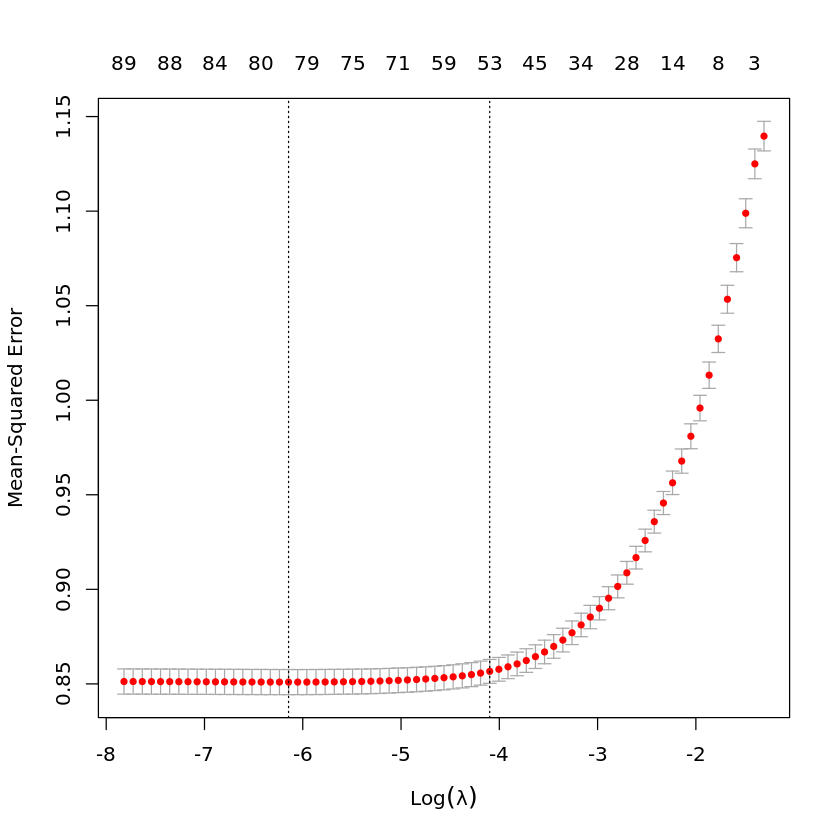

In [8]:
get_lasso_coef(num_out, 'general_health', 0)

y_data
    1  2.05  3.58   4.7     5 
 1072  4821 11952 13433  4536 
y_data
    0     1 
 5893 29921 
[1] 0.0006426364


,s0
,<dbl>
(Intercept),2.102456113
age_years,0.008123429
ADHD,-0.041721800
Acid Reflux,-0.318684183
Acne,0.372646943
Alcohol Or Drug,-0.078537061
Allergies,0.122960048
Anemia,-0.298251646
Anxiety,-0.071902887


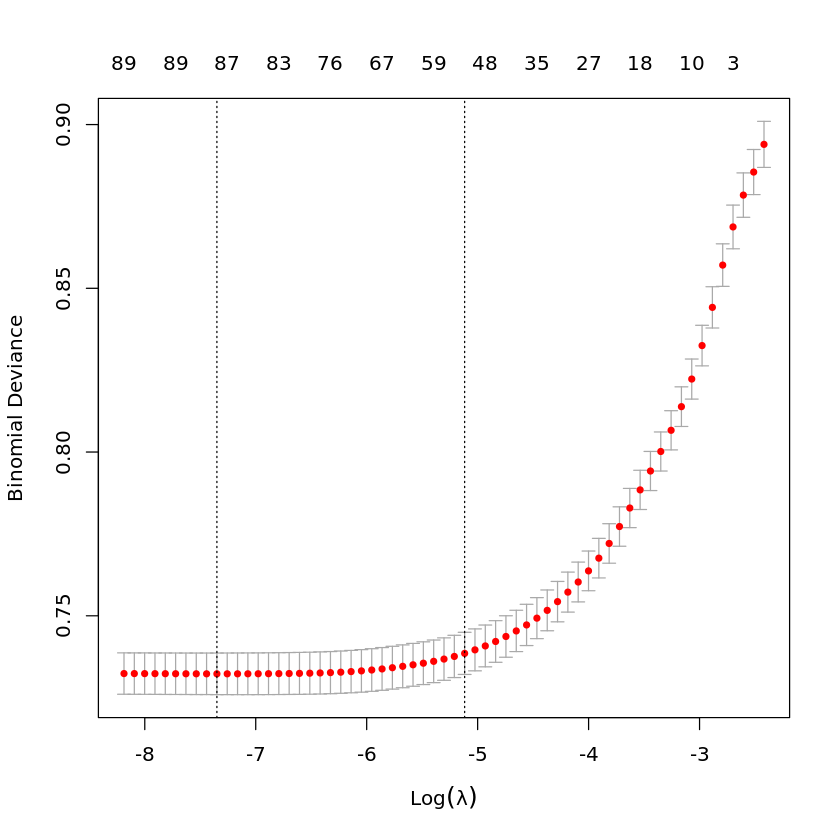

In [26]:
get_lasso_coef(num_out, 'general_health', 1)

y_data
    1  2.05  3.58   4.7     5 
 1072  4821 11952 13433  4536 
y_data
    0     1 
 5893 29921 
[1] 0.04228118


,comorbidity,value
,<chr>,<dbl>
1,(Intercept),1.8511691
2,age_years,0.0000000
3,ADHD,0.0000000
4,Acid Reflux,-0.3026814
5,Acne,0.0000000
6,Alcohol Or Drug,0.0000000
7,Allergies,0.0000000
8,Anemia,0.0000000
9,Anxiety,0.0000000


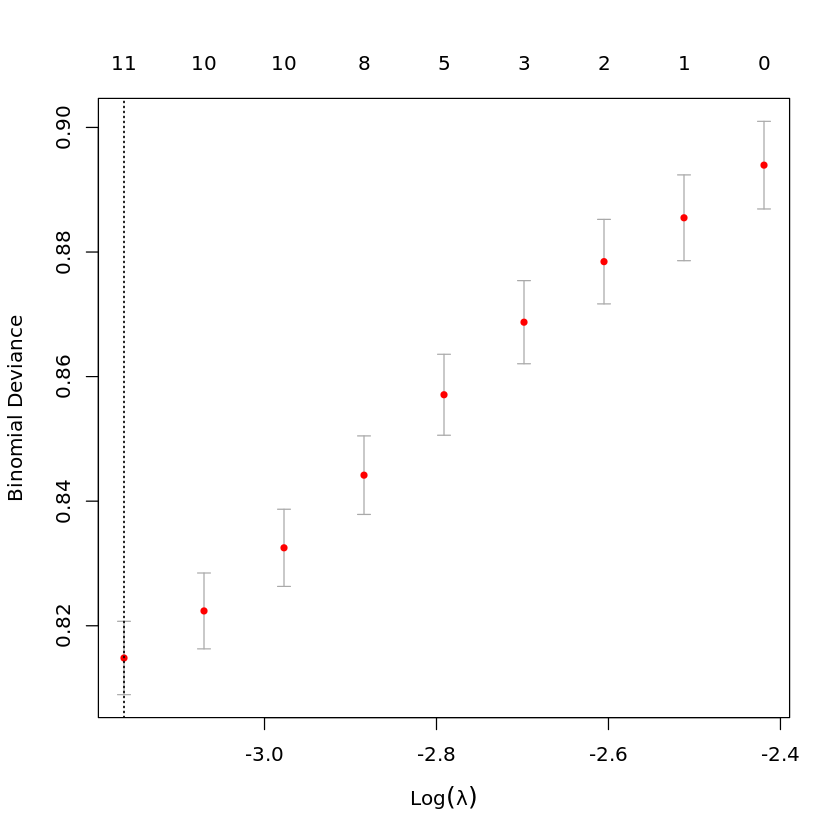

In [49]:
get_lasso_coef(num_out, 'general_health', 1, max_df = 10)

# Use selected lasso variables to create regression models

y_data
    1  2.05  3.58   4.7     5 
 1072  4821 11952 13433  4536 
[1] 0.1286111


,comorbidity,value
,<chr>,<dbl>
1,(Intercept),4.0267600036
2,age_years,0.0000000000
3,ADHD,0.0000000000
4,Acid Reflux,-0.1768034147
5,Acne,0.0000000000
6,Alcohol Or Drug,0.0000000000
7,Allergies,0.0000000000
8,Anemia,-0.0002963341
9,Anxiety,0.0000000000


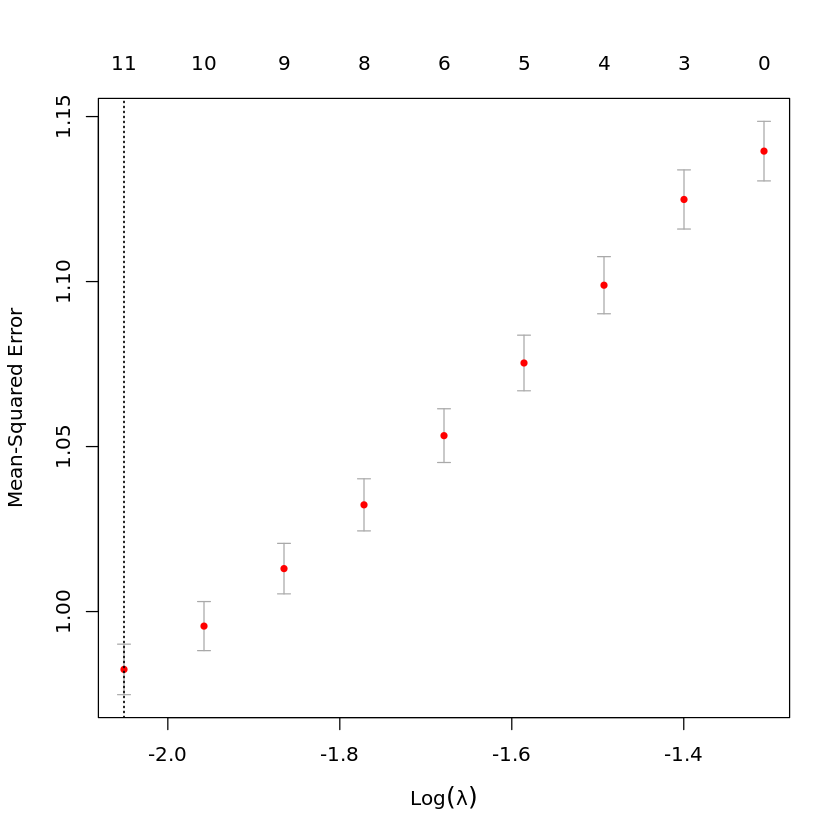

In [75]:
# get coefficients
reg_coef_df <- get_lasso_coef(num_out, 'general_health', is_binary = 0, max_df = 10)
reg_coef_df

In [7]:
# function to create regression models given numeric data and the coefficient values
create_models <- function(numeric_data, coefficients_df, is_linear_model_wanted) {
    # check if age is included in final model
    is_age_included = FALSE
    if (coefficients_df[2,]$value != 0) {
        is_age_included = TRUE
    }
    
    # subset data to selected variables
    non_zero <- coefficients_df[coefficients_df['value'] != 0,][-1,]
    non_zero_comor <- non_zero$comorbidity
    non_zero_comor <- append(non_zero_comor, 'general_health')
    
    if (is_age_included == FALSE) {
        data <- num_out |> 
            select(non_zero_comor) |>
            mutate(across(-general_health, as.factor)) |>
            clean_names()
    }
    else {
        data <- num_out |> 
            select(non_zero_comor) |>
            mutate(across(-c(general_health, age_years), as.factor)) |>
            clean_names()
    }

    # drop unknown values
    known_data <- data[data['general_health'] != 0,]
    
    if (is_linear_model_wanted == 1) {
        lin_mod <- lm(general_health ~ ., data = known_data)
        mod_sum <- summary(lin_mod)
    }
    else {
        # convert values
        outcome_vals <- known_data$general_health
        outcome_vals <- replace(outcome_vals, outcome_vals == 1, 0)
        outcome_vals <- replace(outcome_vals, outcome_vals == 2.05, 0)
        outcome_vals <- replace(outcome_vals, outcome_vals == 3.58, 1)
        outcome_vals <- replace(outcome_vals, outcome_vals == 4.7, 1)
        outcome_vals <- replace(outcome_vals, outcome_vals == 5, 1)

        # change outcome values to binary
        known_data$general_health <- outcome_vals
        known_data <- known_data |> mutate(general_health = as.factor(general_health))

        log_mod <- glm(general_health ~ ., data = known_data, family = "binomial")
        mod_sum <- summary(log_mod)
        
        # get C score
        predictions <- predict(log_mod, type = "response")
        print(roc(known_data$general_health, predictions))
    }
    return(mod_sum)
}

In [77]:
create_models(num_out, reg_coef_df, is_linear_model_wanted = 1)


Call:
lm(formula = general_health ~ ., data = known_data)

Residuals:
    Min      1Q  Median      3Q     Max 
-3.1888 -0.6088  0.5112  0.7725  4.0167 

Coefficients:
                  Estimate Std. Error t value Pr(>|t|)    
(Intercept)       4.188815   0.006161  679.87   <2e-16 ***
acid_reflux1     -0.301661   0.017142  -17.60   <2e-16 ***
anemia1          -0.306071   0.020948  -14.61   <2e-16 ***
chronic_fatigue1 -0.606992   0.029810  -20.36   <2e-16 ***
depression1      -0.261330   0.012861  -20.32   <2e-16 ***
fibromyalgia1    -0.566158   0.035777  -15.82   <2e-16 ***
hypertension1    -0.398659   0.020167  -19.77   <2e-16 ***
migraine1        -0.200256   0.017140  -11.68   <2e-16 ***
neuropathy1      -0.576603   0.037129  -15.53   <2e-16 ***
obesity1         -0.422775   0.018579  -22.75   <2e-16 ***
ptsd1            -0.308388   0.021630  -14.26   <2e-16 ***
type_2_diabetes1 -0.676670   0.035463  -19.08   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 

In [78]:
create_models(num_out, reg_coef_df, is_linear_model_wanted = 0)

Setting levels: control = 0, case = 1

Setting direction: controls < cases




Call:
roc.default(response = known_data$general_health, predictor = predictions)

Data: predictions in 5893 controls (known_data$general_health 0) < 29921 cases (known_data$general_health 1).
Area under the curve: 0.7398



Call:
glm(formula = general_health ~ ., family = "binomial", data = known_data)

Coefficients:
                 Estimate Std. Error z value Pr(>|z|)    
(Intercept)       2.32997    0.02154 108.193  < 2e-16 ***
acid_reflux1     -0.55944    0.04372 -12.795  < 2e-16 ***
anemia1          -0.58953    0.05323 -11.075  < 2e-16 ***
chronic_fatigue1 -1.10520    0.07026 -15.731  < 2e-16 ***
depression1      -0.45520    0.03615 -12.591  < 2e-16 ***
fibromyalgia1    -1.11537    0.08755 -12.740  < 2e-16 ***
hypertension1    -0.73019    0.05021 -14.542  < 2e-16 ***
migraine1        -0.32711    0.04533  -7.216 5.34e-13 ***
neuropathy1      -1.13424    0.09221 -12.300  < 2e-16 ***
obesity1         -0.62783    0.04653 -13.493  < 2e-16 ***
ptsd1            -0.59595    0.05390 -11.056  < 2e-16 ***
type_2_diabetes1 -1.23641    0.08436 -14.656  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 32027

# Overall

In [8]:
# function to create lasso model based on desired outcome variable type
get_lasso_coef_overall <- function(dataframe, is_binary, is_lambda_min, max_df) {
    # make x and y datasets
    x_data <- dataframe |> select(-outcome)
    x_data <- data.matrix(x_data)
    y_data <- dataframe$outcome
    print(table(y_data))
    
    if (is_binary == 1) {
        # make outcome variable binary
        y_data <- replace(y_data, y_data == 1, 0)
        y_data <- replace(y_data, y_data == 2.05, 0)
        y_data <- replace(y_data, y_data == 3.58, 1)
        y_data <- replace(y_data, y_data == 4.7, 1)
        y_data <- replace(y_data, y_data == 5, 1)
        print(table(y_data))

        # lasso with cross validation - calculate lambda
        set.seed(123)
        model <- cv.glmnet(x_data, as.factor(y_data), alpha = 1, nfolds = 10, family = 'binomial',
                           dfmax = max_df)
        if(is_lambda_min == 1) {
            lambda_val <- model$lambda.min
            print(sprintf('Minimum Lambda -> %f', lambda_val))
        }
        else {
            lambda_val <- model$lambda.1se
            print(sprintf('1 SE Lambda -> %f', lambda_val))
        }
        #plot(model)

        # get coefficients - model with minimum lambda
        model_small_lambda <- glmnet(x_data, as.factor(y_data), lambda = lambda_val, alpha = 1, family = 'binomial',
                                     dfmax = max_df)
        coef_result <- coef(model_small_lambda)
    }
    else {
        # lasso with cross validation - calculate lambda
        set.seed(123)
        model <- cv.glmnet(x_data, y_data, alpha = 1, nfolds = 10, 
                           dfmax = max_df)
        if(is_lambda_min == 1) {
            lambda_val <- model$lambda.min
            print(sprintf('Minimum Lambda -> %f', lambda_val))
        }
        else {
            lambda_val <- model$lambda.1se
            print(sprintf('1 SE Lambda -> %f', lambda_val))
        }
        #plot(model)

        # get coefficients - model with minimum lambda
        model_small_lambda <- glmnet(x_data, y_data, lambda = lambda_val, alpha = 1, 
                                     dfmax = max_df)
        coef_result <- coef(model_small_lambda)
    }
    # return coefficients as dataframe
    coef_matrix <- as.matrix(coef_result)
    coef_matrix_df <- as.data.frame(coef_matrix)
    coef_matrix_df <- cbind(comorbidity = rownames(coef_matrix_df), coef_matrix_df)
    rownames(coef_matrix_df) <- 1:nrow(coef_matrix_df)
    colnames(coef_matrix_df) <- c('comorbidity', 'value')
    return(coef_matrix_df)
}

In [9]:
# function to create regression models given numeric data and the coefficient values
create_first_model_overall <- function(dataframe, lasso_coefficients_df, is_logistic_model) {
    # check if age is included in final model
    is_age_included = FALSE
    if (lasso_coefficients_df[2,]$value != 0) {
        is_age_included = TRUE
    }
    
    # subset data to variables with a non-zero coefficient
    non_zero <- lasso_coefficients_df[lasso_coefficients_df['value'] != 0,][-1,]
    non_zero_comors <- non_zero$comorbidity
    num_non_zeros <- length(non_zero_comors)
    print(sprintf('Number of Non-Zero Comorbitities from Lasso Model -> %i', num_non_zeros))
    
    
    #-> since removing age from data

    # check presence of age for variable types
    #if (is_age_included == FALSE) {
    #    data <- dataframe |> 
    #        select(c(all_of(non_zero_comors), outcome)) |>
    #        mutate(across(-outcome, as.factor))
    #}
    #else {
    #    data <- dataframe |> 
    #        select(c(all_of(non_zero_comors), outcome)) |>
    #        mutate(across(-c(outcome, age_years), as.factor))
    #}
    
    data <- dataframe |> select(c(all_of(non_zero_comors), outcome)) |>
                mutate(across(-outcome, as.factor))

    # drop unknown values
    known_data <- data[data$outcome != 0,]
    
    if (is_logistic_model == 0) {
        model <- lm(outcome ~ ., data = known_data)
    }
    else {
        # convert values
        outcome_vals <- known_data$outcome
        outcome_vals <- replace(outcome_vals, outcome_vals == 1, 0)
        outcome_vals <- replace(outcome_vals, outcome_vals == 2.05, 0)
        outcome_vals <- replace(outcome_vals, outcome_vals == 3.58, 1)
        outcome_vals <- replace(outcome_vals, outcome_vals == 4.7, 1)
        outcome_vals <- replace(outcome_vals, outcome_vals == 5, 1)

        # change outcome values to binary
        known_data$outcome <- outcome_vals
        known_data <- known_data |> mutate(outcome = as.factor(outcome))

        model <- glm(outcome ~ ., data = known_data, family = 'binomial')
        
        # get C score
        predictions <- predict(model, type = 'response')
        roc_score <- roc(known_data$outcome, predictions, levels = c(0, 1), direction = '<')
        c_score <- roc_score$auc * 100
        print(sprintf('C Score -> %.2f', c_score))
    }
    return(model)
}

In [10]:
# function to create regression models given numeric data and the coefficient values
create_second_model_overall <- function(dataframe, model_result, is_logistic_model, desired_p_val) {    
    # get significant comorbidities from first model
    model_coef_df <- as.data.frame(coef(summary(model_result)))[-1,]
    if (is_logistic_model == 1) {
        signif_comor_df <- model_coef_df[model_coef_df[,'Pr(>|z|)'] < desired_p_val,]
    }
    else {
        signif_comor_df <- model_coef_df[model_coef_df[,'Pr(>|t|)'] < desired_p_val,]
    }
    signif_comors <- rownames(signif_comor_df)
    num_signif_comor <- length(signif_comors)
    print(sprintf('Number of Significant Non-Zero Comorbitities from Preliminary Model -> %i', num_signif_comor))
    
    # check if age is included in final model
    is_age_included = 'age_years' %in% signif_comors
    
    # check presence of age for variable types
    if (is_age_included == FALSE) {
        # remove '1' from end of coefficient names if exists
        clean_comors <- c()
        for (val in signif_comors) {
            clean_comors <- append(clean_comors, substr(val, 1, nchar(val)-1))
        }
        # subset data
        data <- dataframe |> 
            select(c(clean_comors, outcome)) |>
            mutate(across(-outcome, as.factor))
    }
    else {
        # remove '1' from end of coefficient names if exists
        clean_comors <- c('age_years')
        for (index in 2:length(signif_comors)) {
            val <- signif_comors[index]
            clean_comors <- append(clean_comors, substr(val, 1, nchar(val)-1))
        }
        # subset data
        data <- dataframe |> 
            select(c(clean_comors, outcome)) |>
            mutate(across(-c(outcome, age_years), as.factor))
    }
    print(sprintf('Variables in final dataset (including outcome)                      -> %i', dim(data)[2]))

    # drop unknown values
    known_data <- data[data$outcome != 0,]
    
    if (is_logistic_model == 0) {
        model <- lm(outcome ~ ., data = known_data)
    }
    else {
        # convert values
        outcome_vals <- known_data$outcome
        outcome_vals <- replace(outcome_vals, outcome_vals == 1, 0)
        outcome_vals <- replace(outcome_vals, outcome_vals == 2.05, 0)
        outcome_vals <- replace(outcome_vals, outcome_vals == 3.58, 1)
        outcome_vals <- replace(outcome_vals, outcome_vals == 4.7, 1)
        outcome_vals <- replace(outcome_vals, outcome_vals == 5, 1)

        # change outcome values to binary
        known_data$outcome <- outcome_vals
        known_data <- known_data |> mutate(outcome = as.factor(outcome))

        model <- glm(outcome ~ ., data = known_data, family = 'binomial')
        
        # get C score
        predictions <- predict(model, type = 'response')
        roc_score <- roc(known_data$outcome, predictions, levels = c(0, 1), direction = '<')
        c_score <- roc_score$auc * 100
        print(sprintf('C Score -> %.2f', c_score))
    }
    return(model)
}

In [11]:
# overall function to make more usable
model_main <- function(numeric_dataframe, outcome_variable, is_binary_coef, is_logistic_model, is_lambda_min,
                       desired_p_val = 0.05,
                       max_df = dim(numeric_dataframe)[2]) {
    
    
    # create dataframe for rest of function
    outcome_var_list <- c('general_mental_health', 'general_physical_health',
                          'general_quality', 'general_social', 'general_health')
    remove_outcome_var_list <- outcome_var_list[outcome_var_list != outcome_variable]

    # remove unwanted outcome variables
    numeric_removed <- numeric_dataframe |> select(-all_of(remove_outcome_var_list))

    # drop values with unknown outcome
    numeric_final <- numeric_removed[numeric_removed[outcome_variable] != 0,]

    # change name of outcome variable
    colnames(numeric_final)[ncol(numeric_final)] <- 'outcome'
    
    # run lasso regression model
    lasso_coef <- get_lasso_coef_overall(numeric_final, is_binary_coef, is_lambda_min, max_df)
    
    # create appropriate model wanted [first]
    first_model <- create_first_model_overall(numeric_final, lasso_coef, is_logistic_model)
    
    # create appropriate model wanted [second]
    second_model <- create_second_model_overall(numeric_final, first_model, is_logistic_model, desired_p_val)
    return(second_model)
}

In [12]:
test <- num_out
head(test)

adhd,acid_reflux,acne,alcohol_or_drug,allergies,anemia,anxiety,asthma,astigmatism,atrial_fibrillation,⋯,race_unknown_missing,race_white,ethnicity_hispanic_latino,ethnicity_not_hispanic_latino,ethnicity_unknown_missing,general_mental_health,general_physical_health,general_quality,general_social,general_health
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0,0,0,0,0,0,1,0,1,0,⋯,1,0,0,0,1,3.58,4.70,3.58,4.70,4.70
1,0,0,1,0,0,1,0,0,0,⋯,1,0,0,0,1,3.58,3.58,2.05,3.58,2.05
0,0,0,0,1,0,0,0,0,0,⋯,1,0,0,0,1,3.58,1.00,2.05,2.05,1.00
0,0,0,0,1,0,0,0,0,0,⋯,1,0,0,0,1,3.58,4.70,4.70,2.05,5.00
0,0,0,0,0,0,0,0,1,0,⋯,1,0,0,0,1,1.00,2.05,2.05,2.05,2.05
0,0,0,0,0,0,0,0,0,0,⋯,1,0,0,0,1,2.05,3.58,1.00,2.05,4.70


In [11]:
#c('general_mental_health', 'general_physical_health', 'general_quality', 'general_social', 'general_health')

In [13]:
# try with various values
test_mod <- model_main(numeric_dataframe = test,
                       outcome_variable = 'general_social', 
                       is_binary_coef = 1, 
                       is_logistic_model = 1,
                       is_lambda_min = 0
                       , desired_p_val = 0.001
                       #, max_df = 25
                       )

y_data
    1  2.05  3.58   4.7     5 
  583  2829  8355 14535  9475 
y_data
    0     1 
 3412 32365 
[1] "1 SE Lambda -> 0.005716"
[1] "Number of Non-Zero Comorbitities from Lasso Model -> 33"
[1] "C Score -> 75.85"
[1] "Number of Significant Non-Zero Comorbitities from Preliminary Model -> 20"


Warning message:
“Using an external vector in selections was deprecated in tidyselect 1.1.0.
ℹ Please use `all_of()` or `any_of()` instead.
  # Was:
  data %>% select(clean_comors)

  # Now:
  data %>% select(all_of(clean_comors))

See <https://tidyselect.r-lib.org/reference/faq-external-vector.html>.”


[1] "Variables in final dataset (including outcome)                      -> 21"
[1] "C Score -> 75.18"


In [16]:
# try with different values for maximum degrees of freedom - moves somewhat significantly at 35
for (num_dfs in seq(30, 35, by = 1)) {
    print(sprintf('Maximum degrees of freedom -> %i', num_dfs))
    print(num_dfs)
    test_mod <- model_main(numeric_dataframe = test,
                           outcome_variable = 'general_health', 
                           is_binary_coef = 1, 
                           is_logistic_model = 1,
                           is_lambda_min = 0
                           , desired_p_val = 0.001
                           , max_df = num_dfs
                           )
    writeLines('\n\n\n')
}

[1] "Maximum degrees of freedom -> 30"
[1] 30
y_data
    1  2.05  3.58   4.7     5 
 1072  4821 11952 13433  4536 
y_data
    0     1 
 5893 29921 
[1] "1 SE Lambda -> 0.016677"
[1] "Number of Non-Zero Comorbitities from Lasso Model -> 28"
[1] "C Score -> 77.86"
[1] "Number of Significant Non-Zero Comorbitities from Preliminary Model -> 27"
[1] "Variables in final dataset (including outcome)                      -> 28"
[1] "C Score -> 77.80"




[1] "Maximum degrees of freedom -> 31"
[1] 31
y_data
    1  2.05  3.58   4.7     5 
 1072  4821 11952 13433  4536 
y_data
    0     1 
 5893 29921 
[1] "1 SE Lambda -> 0.016677"
[1] "Number of Non-Zero Comorbitities from Lasso Model -> 28"
[1] "C Score -> 77.86"
[1] "Number of Significant Non-Zero Comorbitities from Preliminary Model -> 27"
[1] "Variables in final dataset (including outcome)                      -> 28"
[1] "C Score -> 77.80"




[1] "Maximum degrees of freedom -> 32"
[1] 32
y_data
    1  2.05  3.58   4.7     5 
 1072  4821 1195

# Get table of comorbiditity presence in final models

In [27]:
get_comor_presence <- function(numeric_dataframe) {
    outcomes <- c('general_mental_health', 'general_physical_health', 
                  'general_quality', 'general_social', 'general_health')    
    
    # output datafram
    res_df <- as.data.frame(colnames(numeric_dataframe[1:(length(numeric_dataframe)-5)]))
    colnames(res_df) <- c('Comorbidity')
    
    for (outcome in outcomes) {
        mod <- model_main(numeric_dataframe = numeric_dataframe,
                          outcome_variable = outcome, 
                          is_binary_coef = 1, 
                          is_logistic_model = 1,
                          is_lambda_min = 0, 
                          desired_p_val = 0.001)

        comors <- rownames(as.data.frame(coef(summary(mod)))[-1,])
        num_comors <- length(comors)

        # check if age is included in final model
        is_age_included = 'age_years' %in% comors

        # check presence of age for variable types
        if (is_age_included == FALSE) {
            # remove '1' from end of coefficient names if exists
            clean_comors <- c()
            for (val in comors) {
                clean_comors <- append(clean_comors, substr(val, 1, nchar(val)-1))
            }
        }
        else {
            # remove '1' from end of coefficient names if exists
            clean_comors <- c('age_years')
            for (index in 2:length(comors)) {
                val <- comors[index]
                clean_comors <- append(clean_comors, substr(val, 1, nchar(val)-1))
            }
        }
        print(sprintf('Outcome: %s - Number of Comorbidities: %i', outcome, length(clean_comors)))
        writeLines('\n')
        
        # get indices of where final model comorbidities are and make value 1
        predictor_vars <- res_df$Comorbidity
        is_included <- rep(0, length(predictor_vars))
        comor_indices <- match(clean_comors, predictor_vars)
        is_included[comor_indices] <- 1
        
        # add 'included' to result dataframe
        res_df[outcome] <- is_included
    }
    return(res_df)
}

In [28]:
testdf <- get_comor_presence(num_out)
testdf

y_data
    1  2.05  3.58   4.7     5 
 1474  6192 11555 11439  5163 
y_data
    0     1 
 7666 28157 
[1] "1 SE Lambda -> 0.009762"
[1] "Number of Non-Zero Comorbitities from Lasso Model -> 15"
[1] "C Score -> 74.62"
[1] "Number of Significant Non-Zero Comorbitities from Preliminary Model -> 15"
[1] "Variables in final dataset (including outcome)                      -> 16"
[1] "C Score -> 74.62"
[1] "Outcome: general_mental_health - Number of Comorbidities: 15"


y_data
    1  2.05  3.58   4.7     5 
 1481  6033 12481 11905  3897 
y_data
    0     1 
 7514 28283 
[1] "1 SE Lambda -> 0.005033"
[1] "Number of Non-Zero Comorbitities from Lasso Model -> 54"
[1] "C Score -> 76.01"
[1] "Number of Significant Non-Zero Comorbitities from Preliminary Model -> 29"
[1] "Variables in final dataset (including outcome)                      -> 30"
[1] "C Score -> 75.43"
[1] "Outcome: general_physical_health - Number of Comorbidities: 29"


y_data
    1  2.05  3.58   4.7     5 
  534  3240  9966 1485

Comorbidity,general_mental_health,general_physical_health,general_quality,general_social,general_health
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
adhd,1,0,1,1,0
acid_reflux,0,1,1,0,1
acne,0,1,0,1,1
alcohol_or_drug,0,0,0,0,0
allergies,1,0,0,0,0
anemia,0,1,0,0,1
anxiety,1,0,0,0,0
asthma,0,1,0,0,1
astigmatism,0,0,0,0,1


In [31]:
testdf |> filter(#general_mental_health == 1 &
                 general_physical_health == 1 &
                 general_quality == 1 &
                 general_social == 1 &
                 general_health == 1)

Comorbidity,general_mental_health,general_physical_health,general_quality,general_social,general_health
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
bipolar,1,1,1,1,1
chronic_fatigue,1,1,1,1,1
depression,1,1,1,1,1
fibromyalgia,0,1,1,1,1
hypertension,0,1,1,1,1
near_sightedness,0,1,1,1,1
neuropathy,0,1,1,1,1
other_bone_joint_muscle_condition,0,1,1,1,1
other_brain_nervous_system,0,1,1,1,1


# Make Coefficient Values Integer

In [32]:
# try with various values - 1se lambda
test_mod <- model_main(numeric_dataframe = num_out,
                       outcome_variable = 'general_health', 
                       is_binary_coef = 1, 
                       is_logistic_model = 1,
                       is_lambda_min = 0
                       , desired_p_val = 0.001
                       #, max_df = 32
                       )

y_data
    1  2.05  3.58   4.7     5 
 1072  4821 11952 13433  4536 
y_data
    0     1 
 5893 29921 
[1] "1 SE Lambda -> 0.006578"
[1] "Number of Non-Zero Comorbitities from Lasso Model -> 50"
[1] "C Score -> 79.10"
[1] "Number of Significant Non-Zero Comorbitities from Preliminary Model -> 37"
[1] "Variables in final dataset (including outcome)                      -> 38"
[1] "C Score -> 78.86"


In [14]:
round_coef <- function(model) {
    # get coefficients
    coef_df <- as.data.frame(coef(summary(model)))[-1,]
    
    # check if age is included in final model
    comors <- rownames(coef_df)
    is_age_included = 'age_years' %in% comors

    # check presence of age for variable types
    if (is_age_included == FALSE) {
        # remove '1' from end of coefficient names if exists
        clean_comors <- c()
        for (val in comors) {
            clean_comors <- append(clean_comors, substr(val, 1, nchar(val)-1))
        }
    }
    else {
        # remove '1' from end of coefficient names if exists
        clean_comors <- c('age_years')
        for (index in 2:length(comors)) {
            val <- comors[index]
            clean_comors <- append(clean_comors, substr(val, 1, nchar(val)-1))
        }
    }
    
    rownames(coef_df) <- clean_comors
    
    min_abs_val <- min(abs(coef_df['Estimate']))
    coef_estimates <- coef_df['Estimate']

    scaled_vals <- c()
    rounded_vals <- c()

    for (est in coef_estimates) {
        new_val <- est/min_abs_val
        rounded_val <- round_any(new_val, 1, round) * -1

        scaled_vals <- append(scaled_vals, new_val)
        rounded_vals <- append(rounded_vals, rounded_val)
    }

    coef_df['scaled_vals'] <- scaled_vals
    coef_df['rounded_vals'] <- rounded_vals
    res_df <- coef_df |> select(Estimate, scaled_vals, rounded_vals)
    return(res_df)
}

In [34]:
rounded_res <- round_coef(test_mod)
head(rounded_res)

,Estimate,scaled_vals,rounded_vals
,<dbl>,<dbl>,<dbl>
acid_reflux,-0.3400898,-2.395906,2
acne,0.3673980,2.588290,-3
anemia,-0.3719151,-2.620113,3
asthma,-0.2785996,-1.962712,2
astigmatism,0.1419462,1.000000,-1
atrial_fibrillation,-0.7012567,-4.940298,5


# Charlson Test

In [36]:
# subset columns to Charlson format
charl_test <- num_out[, 2:18]
head(charl_test)

acid_reflux,acne,alcohol_or_drug,allergies,anemia,anxiety,asthma,astigmatism,atrial_fibrillation,bipolar,breast_cancer,carpal_tunnel,cataracts,chickenpox,chronic_fatigue,chronic_sinus,colon_polyps
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0
0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0
0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0
0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [37]:
charlson_test <- function(dataframe) {
    # subset data by weight groups
    weight_one_data <- dataframe[, 1:10]
    weight_two_data <- dataframe[, 11:14]
    weight_three_data <- unlist(dataframe[, 15])
    weight_four_data <- dataframe[, 16:17]
    
    # total counts by weight
    weight_one_sum <- rowSums(weight_one_data)
    weight_two_sum <- rowSums(weight_two_data)
    weight_four_sum <- rowSums(weight_four_data)
    
    scores <- c()
    
    # iterate through rows
    for (row_index in 1:dim(dataframe)[1]) {
        weight_one_val <- weight_one_sum[row_index]
        weight_two_val <- weight_two_sum[row_index] * 2
        weight_three_val <- weight_three_data[row_index] * 3
        weight_four_val <- weight_four_sum[row_index] * 6
            
        total_score <- weight_one_val + weight_two_val + weight_three_val + weight_four_val
        scores <- append(scores, total_score)
    }
    
    dataframe['charlson_score'] <- scores
    return(dataframe)
}

In [38]:
charlson_test(charl_test[100:150,])
# adhd to atral
# bipolar to cataracts
# chickenpox
# chrnoics

acid_reflux,acne,alcohol_or_drug,allergies,anemia,anxiety,asthma,astigmatism,atrial_fibrillation,bipolar,breast_cancer,carpal_tunnel,cataracts,chickenpox,chronic_fatigue,chronic_sinus,colon_polyps,charlson_score
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1
0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,2
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


# Elixhauser Test

In [39]:
# subset columns to Elixhauser format (those with non-zero point values)
elix_test <- num_out[, 2:22]

# change variable names to elixhauser ones
colnames(elix_test) <- c('Congestive heart failure', 'Cardiac arrhythmias', 'Valvular disease',
                         'Pulmonary circulation disorders', 'Peripheral vascular disorders',
                         'Paralysis', 'Neurodegenerative disorders', 'Chronic pulmonary disease',
                         'Renal failure', 'Liver disease', 'Lymphoma', 'Metastatic cancer',
                         'Solid tumour without metastasis', 'Coagulopathy', 'Obesity', 'Weight loss',
                         'Fluid and electrolyte disorders', 'Blood loss anemia', 'Deficiency anemia',
                         'Drug abuse', 'Depression')

elix_test <- elix_test |> clean_names()

head(elix_test)

congestive_heart_failure,cardiac_arrhythmias,valvular_disease,pulmonary_circulation_disorders,peripheral_vascular_disorders,paralysis,neurodegenerative_disorders,chronic_pulmonary_disease,renal_failure,liver_disease,⋯,metastatic_cancer,solid_tumour_without_metastasis,coagulopathy,obesity,weight_loss,fluid_and_electrolyte_disorders,blood_loss_anemia,deficiency_anemia,drug_abuse,depression
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0,0,0,0,0,1,0,1,0,0,⋯,0,0,0,0,0,0,0,0,1,0
0,0,1,0,0,1,0,0,0,1,⋯,0,0,0,0,0,0,0,0,1,0
0,0,0,1,0,0,0,0,0,1,⋯,0,0,0,0,0,0,0,0,1,0
0,0,0,1,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
0,0,0,0,0,0,0,1,0,0,⋯,0,0,0,0,0,0,0,0,0,0
0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


In [40]:
elixhauser_test <- function(dataframe, points_array) {
    elix_scores <- c()
    
    # iterate through each row
    for (row_index in 1:dim(dataframe)[1]) {
        row_vals <- unlist(dataframe[row_index,], use.names = FALSE)
        row_elix_score <- 0
        
        # iterate through row values/scores
        for (col_index in 1:21) {
            point_val <- points_array[col_index]
            variable_val <- row_vals[col_index]
            elix_point_val <- point_val * variable_val
            row_elix_score <- row_elix_score + elix_point_val
        }
        
        # append elixhauser score
        elix_scores <- append(elix_scores, row_elix_score)
    }
    dataframe['elixhauser_score'] <- elix_scores
    return(dataframe)
}

In [41]:
elix_points <- c(7, 5, -1, 4, 2, 7, 6, 3, 5, 11, 9, 12, 4, 3, -4, 6, 5, -2, -2, -7, -3)
test_df <- elixhauser_test(elix_test[1:10,], elix_points)
test_df

congestive_heart_failure,cardiac_arrhythmias,valvular_disease,pulmonary_circulation_disorders,peripheral_vascular_disorders,paralysis,neurodegenerative_disorders,chronic_pulmonary_disease,renal_failure,liver_disease,⋯,solid_tumour_without_metastasis,coagulopathy,obesity,weight_loss,fluid_and_electrolyte_disorders,blood_loss_anemia,deficiency_anemia,drug_abuse,depression,elixhauser_score
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0,0,0,0,0,1,0,1,0,0,⋯,0,0,0,0,0,0,0,1,0,3
0,0,1,0,0,1,0,0,0,1,⋯,0,0,0,0,0,0,0,1,0,10
0,0,0,1,0,0,0,0,0,1,⋯,0,0,0,0,0,0,0,1,0,8
0,0,0,1,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,4
0,0,0,0,0,0,0,1,0,0,⋯,0,0,0,0,0,0,0,0,0,3
0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,7
0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


# YAMI Test

In [38]:
rounded_res

,Estimate,scaled_vals,rounded_vals
,<dbl>,<dbl>,<dbl>
acid_reflux1,-0.3266829,-1.674325,2
anemia1,-0.3941577,-2.020149,2
asthma1,-0.2661768,-1.364217,1
bipolar1,-0.4053244,-2.077381,2
chronic_fatigue1,-0.7877963,-4.037637,4
depression1,-0.4482084,-2.297171,2
fibromyalgia1,-0.9137989,-4.683430,5
hypertension1,-0.6145834,-3.149881,3
insomnia1,-0.2556839,-1.310439,1


In [15]:
clean_comors <- c('acid_reflux', 'anemia', 'asthma', 'bipolar', 'chronic_fatigue', 'depression', 'fibromyalgia', 
                  'hypertension', 'insomnia', 'irritable_bowel', 'liver_condition', 'memory_loss', 'migraine', 
                  'neuropathy', 'obesity', 'other_bone_joint_muscle_condition', 'other_brain_nervous_system', 
                  'other_diagnosis', 'other_digestive_conditions', 'other_heart_blood', 'other_lung_condition', 
                  'ptsd', 'prediabetes', 'rheumatoid_arthritis', 'sleep_apnea', 'spine_muscle_bone', 
                  'type_2_diabetes', 'race_black', 'race_white', 'ethnicity_hispanic_latino')

yami_score_vals <- c(-2, -2, -1, -2, -4, -2, -5, -3, -1, -1, -3, -4, -1, -4, -2, -2, -3, -2, -4, -2, -3, 
                     -2, -3, -5, -2, -1, -6, -2, 2, -2)

In [16]:
# subset data 
yami_test <- num_out |> select(all_of(clean_comors), general_health)
yami_test <- yami_test[yami_test$general_health != 0,]

# convert values
yami_test <- yami_test |> 
    mutate(general_health = case_when(general_health %in% c(1, 2.05) ~ 0, TRUE ~ 1))

head(yami_test)

acid_reflux,anemia,asthma,bipolar,chronic_fatigue,depression,fibromyalgia,hypertension,insomnia,irritable_bowel,⋯,ptsd,prediabetes,rheumatoid_arthritis,sleep_apnea,spine_muscle_bone,type_2_diabetes,race_black,race_white,ethnicity_hispanic_latino,general_health
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0,0,0,0,0,1,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,1
0,0,0,1,0,1,0,0,0,0,⋯,1,0,0,0,0,0,0,0,0,0
0,0,0,1,0,1,0,1,0,0,⋯,0,0,0,1,0,0,0,0,0,0
0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,1
0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,1


In [17]:
yami_index_test <- function(dataframe, points_array) {
    yami_scores <- c()
    
    # iterate through each row
    for (row_index in 1:dim(dataframe)[1]) {
        row_vals <- unlist(dataframe[row_index,], use.names = FALSE)
        row_yami_score <- 0
        
        # iterate through row values/scores
        for (col_index in 1:length(points_array)) {
            point_val <- points_array[col_index]
            variable_val <- row_vals[col_index]
            yami_point_val <- point_val * variable_val
            row_yami_score <- row_yami_score + yami_point_val
        }
        
        # append YAMI score
        yami_scores <- append(yami_scores, row_yami_score)
    }
    dataframe['yami_score'] <- yami_scores
    return(dataframe)
}

In [18]:
yami_index_test(yami_test[1:10,], yami_score_vals)

acid_reflux,anemia,asthma,bipolar,chronic_fatigue,depression,fibromyalgia,hypertension,insomnia,irritable_bowel,⋯,prediabetes,rheumatoid_arthritis,sleep_apnea,spine_muscle_bone,type_2_diabetes,race_black,race_white,ethnicity_hispanic_latino,general_health,yami_score
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0,0,0,0,0,1,0,0,0,0,⋯,0,0,0,0,0,0,0,0,1,-2
0,0,0,1,0,1,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,-6
0,0,0,1,0,1,0,1,0,0,⋯,0,0,1,0,0,0,0,0,0,-9
0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,1,0
0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,1,-7
1,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,1,-6
0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,1,0,0,0,0,-6
0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,1,-2


# Compare Index Scores

In [26]:
# for test dataset:  subset for each index's comorbidities
# for each index:    create dataframe of -> patient id | index score
# for final dataset: merge by patient id
# testing:           run logistic regression models for each index on outcome

## Test Data

In [44]:
# subset and convert
index_test_data <- num_out[num_out$general_health != 0,]
index_test_data <- index_test_data |> 
    mutate(general_health = case_when(general_health %in% c(1, 2.05) ~ 0, TRUE ~ 1))


# charlson
charl_test_data <- index_test_data[, 2:18]
#charlson_results <- charlson_test(charl_test_data[1:10,]) 
charlson_results <- charlson_test(charl_test_data) 


# elixhauser
elix_test_data <- index_test_data[, 2:22]
elix_points <- c(7, 5, -1, 4, 2, 7, 6, 3, 5, 11, 9, 12, 4, 3, -4, 6, 5, -2, -2, -7, -3)
#elixhauser_results <- elixhauser_test(elix_test_data[1:10,], elix_points) 
elixhauser_results <- elixhauser_test(elix_test_data, elix_points) 

In [61]:
# yami
clean_comors <- c('acid_reflux', 'anemia', 'asthma', 'bipolar', 'chronic_fatigue', 'depression', 'fibromyalgia', 
                  'hypertension', 'insomnia', 'irritable_bowel', 'liver_condition', 'memory_loss', 'migraine', 
                  'neuropathy', 'obesity', 'other_bone_joint_muscle_condition', 'other_brain_nervous_system', 
                  'other_diagnosis', 'other_digestive_conditions', 'other_heart_blood', 'other_lung_condition', 
                  'ptsd', 'prediabetes', 'rheumatoid_arthritis', 'sleep_apnea', 'spine_muscle_bone', 
                  'type_2_diabetes', 'race_black', 'race_white', 'ethnicity_hispanic_latino')

yami_score_vals <- c(2, 2, 1, 2, 4, 2, 5, 3, 1, 1, 3, 4, 1, 4, 2, 2, 3, 2, 4, 2, 3, 
                     2, 3, 5, 2, 1, 6, 2, -2, 2)

yami_test_data <- index_test_data |> select(all_of(clean_comors), general_health)
#yami_results <- yami_index_test(yami_test_data[1:10,], yami_score_vals)
yami_results <- yami_index_test(yami_test_data, yami_score_vals)

## Assuming index scoring is already completed ... 

In [62]:
# final data - create new columns in this instance due to how data is organized
final_index_data <- charlson_results
final_index_data$elixhauser_score <- elixhauser_results$elixhauser_score
final_index_data$yami_score <- yami_results$yami_score
final_index_data$general_health <- yami_results$general_health
final_index_data <- final_index_data |> select(charlson_score, elixhauser_score, yami_score, general_health)
final_index_data$general_health <- factor(final_index_data$general_health, ordered = TRUE)
head(final_index_data)
print(dim(final_index_data))

charlson_score,elixhauser_score,yami_score,general_health
<dbl>,<dbl>,<dbl>,<ord>
2,8,2,1
5,23,6,0
3,8,9,0
1,2,0,1
1,5,0,0
0,0,7,1


[1] 35814     4


In [16]:
calculate_index_c_scores <- function(dataframe) {
    # create models
    charlson_model <- glm(general_health ~ charlson_score, data = dataframe, family = 'binomial')
    elixhauser_model <- glm(general_health ~ elixhauser_score, data = dataframe, family = 'binomial')
    yami_model <- glm(general_health ~ yami_score, data = dataframe, family = 'binomial')
        
    # get model predictons
    charlson_pred <- predict(charlson_model, type = 'response')
    elixhauser_pred <- predict(elixhauser_model, type = 'response')
    yami_pred <- predict(yami_model, type = 'response')

    # calculate C scores
    charlson_c <- roc(dataframe$general_health, charlson_pred, levels = c(0, 1), direction = '<')$auc * 100
    elixhauser_c <- roc(dataframe$general_health, elixhauser_pred, levels = c(0, 1), direction = '<')$auc * 100
    yami_c <- roc(dataframe$general_health, yami_pred, levels = c(0, 1), direction = '<')$auc * 100
    
    print(sprintf('Charlson C Score   -> %.2f', charlson_c))
    print(sprintf('Elixhauser C Score -> %.2f', elixhauser_c))
    print(sprintf('YAMI C Score       -> %.2f', yami_c))
}

In [23]:
calculate_index_c_scores(final_index_data)

[1] "Charlson C Score   -> 67.15"
[1] "Elixhauser C Score -> 66.27"
[1] "YAMI C Score       -> 78.10"


# CV Index C Scores

In [18]:
calculate_index_c_scores <- function(dataframe) {
    # create models
    charlson_model <- glm(general_health ~ charlson_score, data = dataframe, family = 'binomial')
    elixhauser_model <- glm(general_health ~ elixhauser_score, data = dataframe, family = 'binomial')
    yami_model <- glm(general_health ~ yami_score, data = dataframe, family = 'binomial')
        
    # get model predictons
    charlson_pred <- predict(charlson_model, type = 'response')
    elixhauser_pred <- predict(elixhauser_model, type = 'response')
    yami_pred <- predict(yami_model, type = 'response')
    actual_values <- dataframe$general_health

    # calculate C scores
    charlson_c <- roc(actual_values, charlson_pred, levels = c(0, 1), direction = '<', percent = TRUE)$auc
    elixhauser_c <- roc(actual_values, elixhauser_pred, levels = c(0, 1), direction = '<', percent = TRUE)$auc
    yami_c <- roc(actual_values, yami_pred, levels = c(0, 1), direction = '<', percent = TRUE)$auc
    
    charlson_rounded <- round(charlson_c, 2)
    elixhauser_rounded <- round(elixhauser_c, 2)
    yami_rounded <- round(yami_c, 2)
    
    print(sprintf('Charlson C Score   -> %.2f', charlson_rounded))
    print(sprintf('Elixhauser C Score -> %.2f', elixhauser_rounded))
    print(sprintf('YAMI C Score       -> %.2f', yami_rounded))
    
    return_obj <- list('charlson_c' = charlson_rounded, 
                       'elixhauser_c' = elixhauser_rounded,
                       'yami_c' = yami_rounded,
                       'charlson_pred' = charlson_pred,
                       'elixhauser_pred' = elixhauser_pred,
                       'yami_pred' = yami_pred,
                       'actual_values' = actual_values)
    
    return(return_obj)
}

#calculate_index_c_scores(final_index_data[1:10,])

In [19]:
index_cv_c_scores <- function(dataframe, number_of_folds) {
    set.seed(123)
    all_charlson_c <- c()
    all_elixhauser_c <- c()
    all_yami_c <- c()
    
    all_charlson_pred <- c()
    all_elixhauser_pred <- c()
    all_yami_pred <- c()
    
    actual_values <- c()
    
    # split indices of data by amount of folds
    fold <- createFolds(dataframe$general_health, k = number_of_folds, list = TRUE, returnTrain = FALSE)

    # iterate through folds and calculate C score for each index
    for (fold_index in 1:number_of_folds) {
        print(sprintf('Fold %i out of %i', fold_index, number_of_folds))
        # subset data by fold indices
        fold_indices <- unlist(fold[fold_index], use.names = FALSE)
        fold_data <- dataframe[fold_indices,]
        
        # calculate C scores
        c_scores <- calculate_index_c_scores(fold_data)
        all_charlson_c <- append(all_charlson_c, c_scores$charlson_c)
        all_elixhauser_c <- append(all_elixhauser_c, c_scores$elixhauser_c)
        all_yami_c <- append(all_yami_c, c_scores$yami_c)
        
        # to account for randomized observation order from folds
        all_charlson_pred <- append(all_charlson_pred, c_scores$charlson_pred)
        all_elixhauser_pred <- append(all_elixhauser_pred, c_scores$elixhauser_pred)
        all_yami_pred <- append(all_yami_pred, c_scores$yami_pred)
        actual_values <- append(actual_values, c_scores$actual_values)
        
        writeLines('\n')
    }
    # get average C scores
    avg_charlson <- round(mean(all_charlson_c), 2)
    avg_elixhauser <- round(mean(all_elixhauser_c), 2)
    avg_yami <- round(mean(all_yami_c), 2)
    
    print(sprintf('Average Charlson C Score   -> %.2f', avg_charlson))
    print(sprintf('Average Elixhauser C Score -> %.2f', avg_elixhauser))
    print(sprintf('Average YAMI C Score       -> %.2f', avg_yami))
    
    # plot ROC curves for each index
    plot.roc(actual_values, all_charlson_pred, percent = TRUE, 
             print.auc = TRUE, main = 'Charlson Index ROC Curve', levels = c(0, 1), direction = '<')
    plot.roc(actual_values, all_elixhauser_pred, percent = TRUE, 
             print.auc = TRUE, main = 'Elixhauser Index ROC Curve', levels = c(0, 1), direction = '<')
    plot.roc(actual_values, all_yami_pred, percent = TRUE, 
             print.auc = TRUE, main = 'YAMI Index ROC Curve', levels = c(0, 1), direction = '<')
}

[1] "Fold 1 out of 5"
[1] "Charlson C Score   -> 66.26"
[1] "Elixhauser C Score -> 65.97"
[1] "YAMI C Score       -> 77.64"


[1] "Fold 2 out of 5"
[1] "Charlson C Score   -> 68.38"
[1] "Elixhauser C Score -> 66.96"
[1] "YAMI C Score       -> 79.51"


[1] "Fold 3 out of 5"
[1] "Charlson C Score   -> 66.89"
[1] "Elixhauser C Score -> 65.72"
[1] "YAMI C Score       -> 77.49"


[1] "Fold 4 out of 5"
[1] "Charlson C Score   -> 66.02"
[1] "Elixhauser C Score -> 65.30"
[1] "YAMI C Score       -> 77.28"


[1] "Fold 5 out of 5"
[1] "Charlson C Score   -> 68.18"
[1] "Elixhauser C Score -> 67.38"
[1] "YAMI C Score       -> 78.59"


[1] "Average Charlson C Score   -> 67.15"
[1] "Average Elixhauser C Score -> 66.27"
[1] "Average YAMI C Score       -> 78.10"


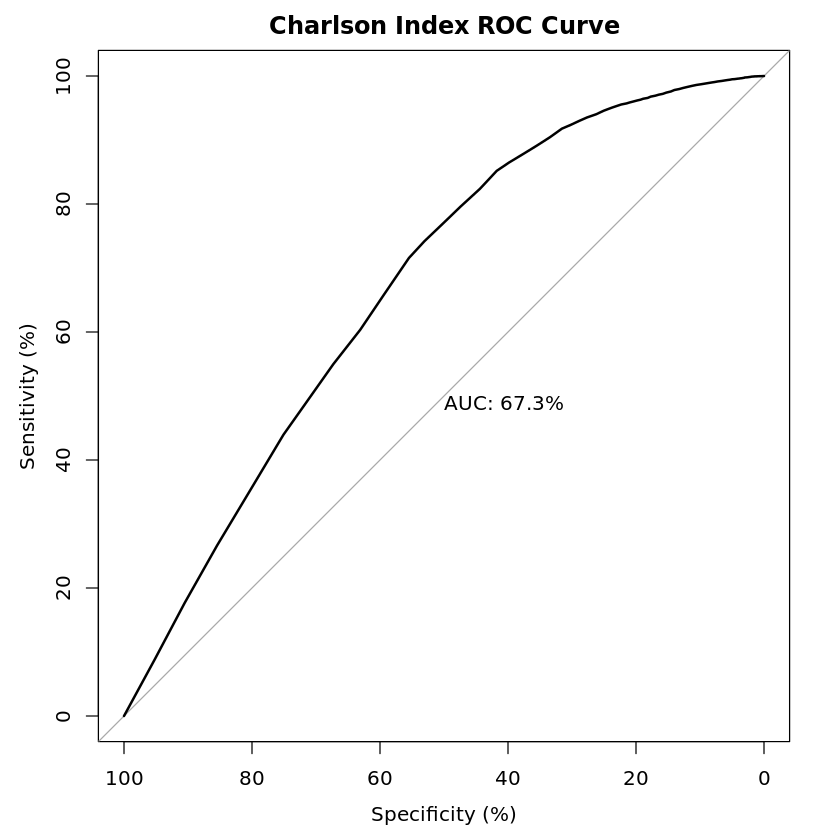

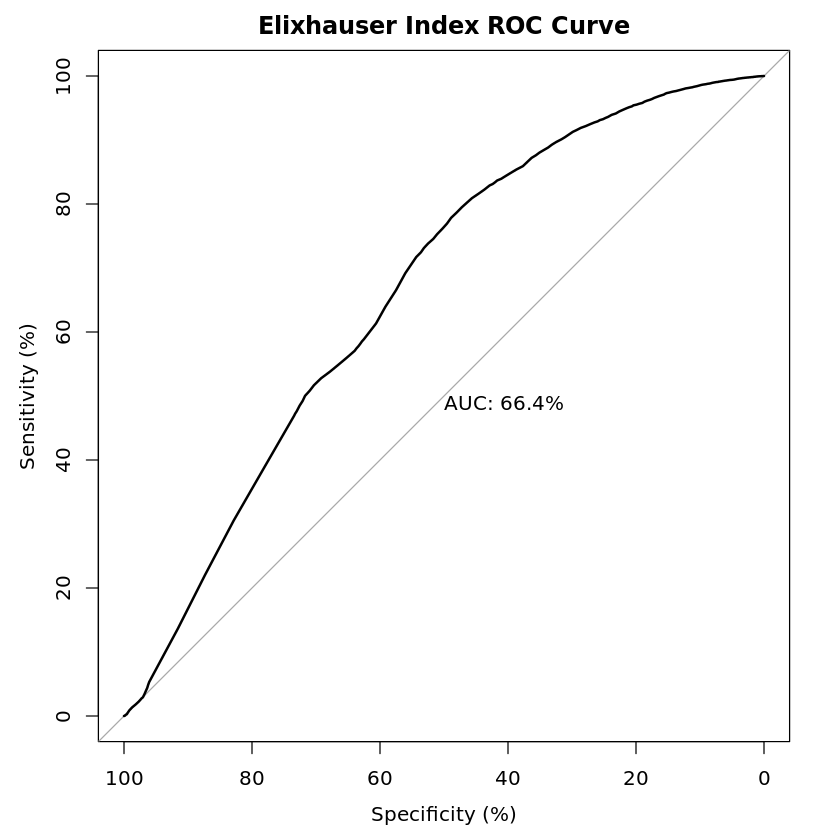

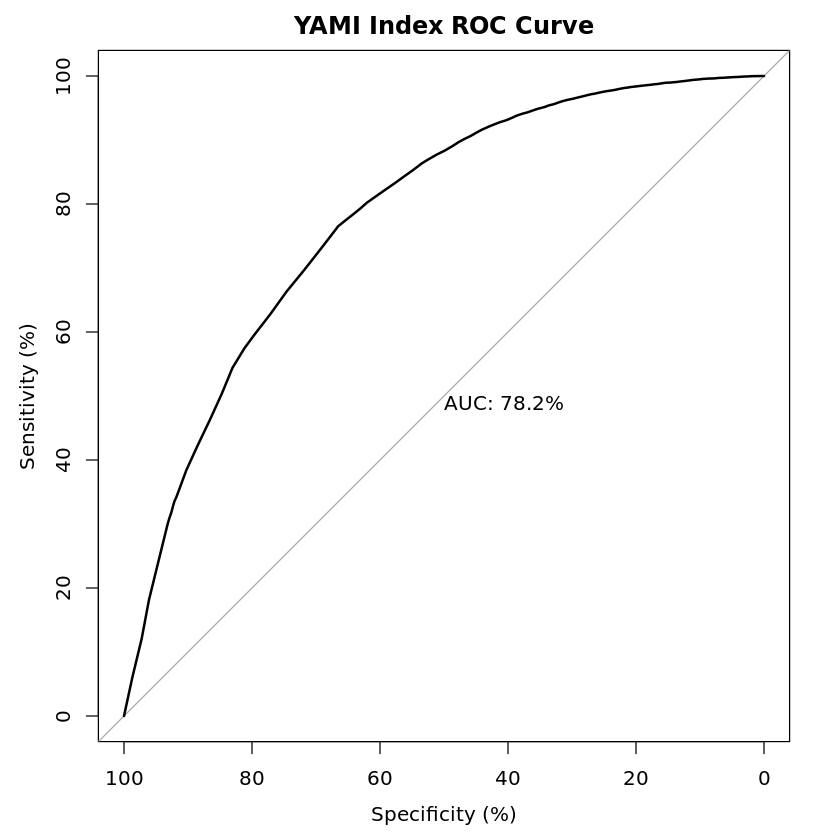

In [94]:
index_cv_c_scores(final_index_data, 5)

# Compare YAMI scores by outcome

In [17]:
# try with various values - 1se lambda
test_mod <- model_main(numeric_dataframe = num_out,
                       outcome_variable = 'general_physical_health', 
                       is_binary_coef = 1, 
                       is_logistic_model = 1,
                       is_lambda_min = 0
                       , desired_p_val = 0.001
                       #, max_df = 32
                       )

rounded_res <- round_coef(test_mod)

test <- rounded_res |> select(rounded_vals)
test_data <- num_out[1:10,]

comors <- rownames(test)
scores <- test$rounded_vals

temp <- test_data |> select(all_of(comors))
yami_index_test(temp, scores)

y_data
    1  2.05  3.58   4.7     5 
 1481  6033 12481 11905  3897 
y_data
    0     1 
 7514 28283 
[1] "1 SE Lambda -> 0.005033"
[1] "Number of Non-Zero Comorbitities from Lasso Model -> 54"
[1] "C Score -> 76.01"
[1] "Number of Significant Non-Zero Comorbitities from Preliminary Model -> 29"
[1] "Variables in final dataset (including outcome)                      -> 30"
[1] "C Score -> 75.43"


acid_reflux,acne,anemia,asthma,bipolar,chronic_fatigue,depression,fibromyalgia,hypertension,hypothyroidism,⋯,prediabetes,rheumatoid_arthritis,sleep_apnea,spine_muscle_bone,type_2_diabetes,gender_other,race_black,race_white,ethnicity_hispanic_latino,yami_score
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0,0,0,0,0,0,1,0,0,0,⋯,0,0,0,0,0,0,0,0,0,2
0,0,0,0,1,0,1,0,0,0,⋯,0,0,0,0,0,0,0,0,0,7
0,0,0,0,1,0,1,0,1,0,⋯,0,0,1,0,0,0,0,0,0,10
0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,-1
0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,1,0,0,0,2
0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,4
1,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,5
0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,1,0,0,0,0,5
0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,2


In [ ]:
head(rounded_res)

In [18]:
get_all_yami_scores <- function(numeric_dataframe) {
    outcomes <- c('general_mental_health', 'general_physical_health', 
                  'general_quality', 'general_social', 'general_health')
    
    res_df <- numeric_dataframe |> select(all_of(outcomes))
    
    for (outcome_var in outcomes) {
    
        # create model
        test_mod <- model_main(numeric_dataframe = numeric_dataframe,
                               outcome_variable = outcome_var, 
                               is_binary_coef = 1, 
                               is_logistic_model = 1,
                               is_lambda_min = 0
                               , desired_p_val = 0.001    
                               )

        # get rounded model coefficients
        rounded_res <- round_coef(test_mod)
        final_comors <- rownames(rounded_res)
        scores <- rounded_res$rounded_vals

        # subset data by final comorbiditiies
        temp <- numeric_dataframe |> select(all_of(final_comors))
        test_res <- yami_index_test(temp, scores)
        res_df[outcome_var] <- test_res$yami_score
    }
    
    return(res_df)
}

In [19]:
all_test <- get_all_yami_scores(num_out)
head(all_test)

y_data
    1  2.05  3.58   4.7     5 
 1474  6192 11555 11439  5163 
y_data
    0     1 
 7666 28157 
[1] "1 SE Lambda -> 0.009762"
[1] "Number of Non-Zero Comorbitities from Lasso Model -> 15"
[1] "C Score -> 74.62"
[1] "Number of Significant Non-Zero Comorbitities from Preliminary Model -> 15"
[1] "Variables in final dataset (including outcome)                      -> 16"
[1] "C Score -> 74.62"
y_data
    1  2.05  3.58   4.7     5 
 1481  6033 12481 11905  3897 
y_data
    0     1 
 7514 28283 
[1] "1 SE Lambda -> 0.005033"
[1] "Number of Non-Zero Comorbitities from Lasso Model -> 54"
[1] "C Score -> 76.01"
[1] "Number of Significant Non-Zero Comorbitities from Preliminary Model -> 29"
[1] "Variables in final dataset (including outcome)                      -> 30"
[1] "C Score -> 75.43"
y_data
    1  2.05  3.58   4.7     5 
  534  3240  9966 14850  7219 
y_data
    0     1 
 3774 32035 
[1] "1 SE Lambda -> 0.005610"
[1] "Number of Non-Zero Comorbitities from Lasso Model -> 42"
[1] "C

general_mental_health,general_physical_health,general_quality,general_social,general_health
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
13,2,1,3,1
21,7,9,11,9
11,10,7,9,13
0,-1,-2,-1,-1
6,2,1,2,3
4,4,4,6,10


In [20]:
test_num <- num_out[, (ncol(num_out)-4):ncol(num_out)]
test_num <- replace(test_num, test_num == 1, 0)
test_num <- replace(test_num, test_num == 2.05, 0)
test_num <- replace(test_num, test_num == 3.58, 1)
test_num <- replace(test_num, test_num == 4.7, 1)
test_num <- replace(test_num, test_num == 5, 1)

test_num['mental_score'] <- all_test$general_mental_health
test_num['physical_score'] <- all_test$general_physical_health
test_num['quality_score'] <- all_test$general_quality
test_num['social_score'] <- all_test$general_social
test_num['health_score'] <- all_test$general_health

head(test_num)

general_mental_health,general_physical_health,general_quality,general_social,general_health,mental_score,physical_score,quality_score,social_score,health_score
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,1,1,1,13,2,1,3,1
1,1,0,1,0,21,7,9,11,9
1,0,0,0,0,11,10,7,9,13
1,1,1,0,1,0,-1,-2,-1,-1
0,0,0,0,0,6,2,1,2,3
0,1,0,0,1,4,4,4,6,10


In [31]:
test_func <- function(dataframe, predictor_var, outcome_var) {
    # drop values with unknown outcome
    known_data <- dataframe |> select(predictor_var, outcome_var)
    colnames(known_data) <- c('predictor', 'outcome')
    
    # create model
    model <- lm(outcome ~ predictor, data = known_data)
        
    # get model R2 score
    r_score <- summary(model)$r.squared
    print(sprintf('R2 Score -> %.2f', r_score))
}

In [32]:
test_func(test_num, 'physical_score', 'general_mental_health')
test_func(test_num, 'quality_score', 'general_mental_health')
test_func(test_num, 'social_score', 'general_mental_health')
test_func(test_num, 'health_score', 'general_mental_health')
writeLines('\n')

test_func(test_num, 'mental_score', 'general_physical_health')
test_func(test_num, 'quality_score', 'general_physical_health')
test_func(test_num, 'social_score', 'general_physical_health')
test_func(test_num, 'health_score', 'general_physical_health')
writeLines('\n')

test_func(test_num, 'physical_score', 'general_quality')
test_func(test_num, 'mental_score', 'general_quality')
test_func(test_num, 'social_score', 'general_quality')
test_func(test_num, 'health_score', 'general_quality')
writeLines('\n')

test_func(test_num, 'physical_score', 'general_social')
test_func(test_num, 'quality_score', 'general_social')
test_func(test_num, 'mental_score', 'general_social')
test_func(test_num, 'health_score', 'general_social')
writeLines('\n')

test_func(test_num, 'physical_score', 'general_health')
test_func(test_num, 'quality_score', 'general_health')
test_func(test_num, 'social_score', 'general_health')
test_func(test_num, 'mental_score', 'general_health')

[1] "R2 Score -> 0.07"
[1] "R2 Score -> 0.09"
[1] "R2 Score -> 0.13"
[1] "R2 Score -> 0.07"


[1] "R2 Score -> 0.06"
[1] "R2 Score -> 0.14"
[1] "R2 Score -> 0.12"
[1] "R2 Score -> 0.17"


[1] "R2 Score -> 0.12"
[1] "R2 Score -> 0.06"
[1] "R2 Score -> 0.11"
[1] "R2 Score -> 0.12"


[1] "R2 Score -> 0.09"
[1] "R2 Score -> 0.10"
[1] "R2 Score -> 0.06"
[1] "R2 Score -> 0.09"


[1] "R2 Score -> 0.18"
[1] "R2 Score -> 0.16"
[1] "R2 Score -> 0.14"
[1] "R2 Score -> 0.07"
